# **랭그래프**(**LangGraph**)

## 1. 랭그래프란(LangGraph)

- **LangGraph**는 LangChain 생태계에서 개발된 **그래프구조 기반 워크플로우 및 에이전트 개발을 위한 런타임 프레임워크**이다.
- LangGraph는 선형적 흐름이 아닌 **비선형적인 복잡한 흐름 구조의 AI 에이전트 애플리케이션을 견고하고 재현 가능하게**(**build reliable**) 구성할 수 있도록 설계되었다.
- LangGraph의 가장 큰 특징은 **사이클**(**순환 구조**)을 지원한다는 점이다. 이는 특정 조건에 따라 이전 단계로 돌아가거나 다른 경로를 선택할 수 있음을 의미한다.   
예를 들어, 검색 결과가 만족스럽지 않을 때 다시 검색을 수행하거나, 답변의 품질이 낮을 때 재생성을 요청하는 등의 복잡한 로직을 구현할 수 있다.

> **그래프**(**Graph**) **구조**
> - 데이터를 저장하고 조직화하는 자료구조 중 하나로 **데이터 간의 관계를 중심으로 정보를 표현하는 방식**의 자료구조다.
> - 데이터를 나타내는 **Node**(**노드**)와 Node와 Node를 연결하여 관계를 나타내는 **Edge**(**엣지**)로 데이터간의 구조를 표현한다.
>     - LangGraph는 **Node가 작업(Task)을 수행하고, Edge가 작업의 흐름**(**Control Flow**)을 정의한다.
>
> **런타임 프레임워크**(**Runtime Framework**)    
> - 애플리케이션이 실행되는 동안(Runtime)에 필요한 기능과 실행 환경을 제공하는 프레임워크를 말한다. 
> - 즉 프로그램이 동작하는 동안 필요한 공통 기능을 대신 처리해 주는 프레임워크이다.

## 2. LangGraph 핵심개념

- **그래프 기반 실행**: 애플리케이션의 실행 흐름을 **노드**(**node**)와 **엣지**(**edge**)로 구성된 그래프로 표현하여 분기, 병렬, 반복 구조를 자연스럽게 다룸.
- **상태 유지(stateful):** 실행 중인 에이전트의 상태(context)를 런타임이 관리하며 중단/재개 시에도 상태가 유지되도록 한다.
- **장기 실행(durable workflows):** 서버 재시작, 장시간 실행 등 프로덕션 조건에서도 상태를 유지하며 워크플로우를 이어갈 수 있는 기능 포함하고 있다.
- **멀티 에이전트 및 상호작용:** 여러 AI 에이전트가 협력하여 복잡한 작업을 수행할 수 있는 환경을 제공한다.


## 3. 랭체인(LangChain)과의 관계

- **LangGraph는 LangChain의 기능을 확장하여 만들어진 프레임워크이다.** 
  - LangGraph는 LangChain에서 제공하는 여러 구성 요소(모델 호출, 도구 등)를 **low level에서 제어**할 수 있게 확장한 프레임워크이다.
    - LangGraph는 개발자가 모델 호출과 도구 실행 등의 순서, 조건에 따른 분기등을 직접 구성할 수 있다.
  - 필요 시 LangChain 에이전트를 LangGraph 워크플로우내의 Node로 사용할 수 있는 **상호 보완적 관계**이다.


### 비교

| 비교 항목            | **LangChain**                        | **LangGraph**                            |  
| ------------------ | ------------------------------------- | --------------------------------------- | 
| 실행 흐름            | **선형/순차 중심** 워크플로우         | **그래프 기반** 복잡한 흐름 (분기·루프·상태 흐름)  |
| 상태 관리            | 기본 메모리/세션 중심                 | **지속 상태(durable)**, 런타임 저장·복원        |
| 추상화 수준          | `LCEL`을 이용한**고수준(high-level)** API | **저수준(low-level)** 실행 제어           | 
| 적합한 용도          | 간단한 에이전트 & 워크플로우          | 복잡한 실행흐름의 멀티 에이전트, 상태 기반 시스템 등 |



# 랭그래프 기본 구조

## 1. 노드(Node) 와 엣지(Edge)

랭그래프의 기본 구조는 **노드**(**Node)** 와 **엣지**(**Edge**)로 구성된다.

### **노드**(**Node**): 
- 그래프 상의 처리 단위
- 실제 작업을 수행하는 Python 함수들로, 각각의 노드는 특정 로직을 담당한다. 
- 노드는 현재 상태를 입력으로 받아서 작업을 수행하고, 업데이트된 상태를 반환한다.
- 예를 들어, LLM 호출, 문서 검색, 데이터 처리 등의 기능을 수행할 수 있다.
- **특수노드**
  - `START`
    - Graph의 시작점(Entry Point)를 나타내는 특수 노드. 
    - `langgraph.graph.START` 상수를 이용해 지정한다.
  - `END`
    - Graph의 종료점(Terminal Point)를 나타내는 특수 노드. 
    - `langgraph.graph.END` 상수를 이용해 지정한다.
  - `START`, `END` 는 일반 노드와 다르게 
    - 실행함수가 없다.
    - State(상태)를 처리하지 않는다.
    - add_node()로 Graph에 등록하지 않는다.
    - 단지 그래프의 시작과 끝을 나타내기 위한 예약된 상수이다.
  
### **엣지**(**Edge**):
-  노드 간의 연결을 정의하며, 다음에 어떤 노드를 실행할지 결정하는 역할을 한다. 
-  엣지는 워크플로우의 **흐름을 제어**하고 조건부 라우팅을 통해 **분기, 반복**을 가능하게 한다.

## 2. 상태(State)

- 상태(State)는 Graph가 실행되는 동안 유지되는 값들의 저장소/메모리 이다.
- 에이전트 실행 중 모든 노드가 이 상태에 접근하여 값들을 조회할 수 있으며, 각 노드들은 작업 결과를 State에 업데이트할 수 있다. 
- 상태(State)는 에이전트 실행중에 key-value 형태로 관리되는 Dictionary 이다. State Schema(상태 구조/설계도) 를 먼저 정의하고 그것을 Graph 생성시 전달한다. 
  - State Schema는 State의 Field(속성, 구성요소)들을 정의한 것이다.
  - State schema에 정의된 key의 Field들만 State에 저장되어 관리된다.
  - State Schema는 **TypedDict 또는 pydantic.BaseModel을 상속한 클래스로 정의**한다.
  - 노드들은 State Schema에 정의된 Field들만 상태로 저장할 수 있다.

- **상태(State)의 주요 역할**
    - **전체 워크플로우의 컨텍스트 유지**
        -  에이전트가 여러 단계를 실행하는 동안 처리 과정에서 필요한 모든 정보를 한 곳(상태-dict)에서 관리한다
    - **노드 간 정보 공유**
        -  한 노드의 실행 결과를 state 필드에 저장하고, 다른 노드가 이를 조회해 사용한다. 이를 통해 노드들이 데이터를 공유할 수 있다.
    - **진행 상황 추적**
        -  에이전트가 현재 실행 중이거나 다음에 실행될 노드가 무엇인지, 이미 완료된 태스크는 무엇인지, 그리고 사용자 승인(HITL) 같은 의사결정 정보까지 state의 필드로 기록할 수 있다. 
        -  이 정보들을 기반으로 그래프 실행 흐름을 조율하고, 조건 분기나 다음 단계 실행을 관리·추적할 수 있게 한다.


## 3. StateGraph

- StateGraph는 LangGraph의 핵심 클래스로, 상태(State)를 기반으로 동작하는 그래프를 정의하는 역할을 한다.
- StateGraph는 그래프에서 사용할 상태(State)의 구조(Schema)와 상태 업데이트 규칙을 정의한다.
- 그래프 실행 중에는 현재 상태가 모든 노드 사이에서 공유되도록 하며, 각 노드가 반환한 값은 StateGraph가 정의한 규칙에 따라 기존 상태와 병합되어 다음 노드로 전달된다.
- StateGraph를 생성할 때 상태 스키마를 지정하며, 각 노드(Node)는 상태를 dict로 받아서 사용할 수 있고 실행 결과를 dict 형태로 반환하여 상태를 갱신한다.

## 4. 랭그래프에서 상태관리

랭그래프에서 상태 관리는 두 가지 방식으로 이루어진다:

1. **완전 재정의 방식**:
   - 기본적으로 상태 필드(State Field)는 노드가 반환한 값으로 기존 값을 대체한다.
   - 동일한 필드에 새로운 값이 반환되면 이전 값은 사라지고 새로운 값이 저장된다.
     - key가 같으면 동일한 Field이다.
2. **업데이트 방식**: 
   - **Reducer**를 이용한다.
   - 리스트와 같이 기존 값을 유지하면서 새로운 값을 추가해야 하는 경우 Reducer를 사용할 수 있다.
   - **Reducer**는 기존 상태 값과 노드가 반환한 값을 병합하는 규칙을 정의한다. (병합 처리하는 함수이다.)
   - 대표적으로 채팅 메시지를 누적하기 위해 add_messages Reducer를 사용한다.

In [1]:
!uv pip install langgraph

Checked 1 package in 1.72s


# 랭그래프 구현

- **설치**
  - `pip install langgraph`
  
## 1. 상태(State) 구조(schema) 정의

- 랭그래프를 구현하기 위해서는 먼저 State 클래스를 정의 한다.
  - State는 `TypedDict`, `pydantic.BaseModel`를 상속받아 정의한다.
    > **TypeDict**: Dictionary Type hint를 위한 클래스로 key와 value의 타입을 정의한다.

  - class 변수로 Field들을 정의 한다.
    - type hint를 이용해 각 Field(key)가 어떤 타입의 값을 가질 지 선언한다. 
    - 리스트 병합 같은 결합 규칙이 필요한 필드는 `Annotated[..., reducer]` 형태로 reducer 함수를 지정한다.
    - Reducer는 field가 가진 기존 값에 노드가 추가한 새 값을 어떻게 결합할지 정의한다 (예: 리스트 추가, 값 덮어쓰기, 사용자 정의 병합 등)
  - State 클래스는 그래프 실행 전반에서 Node들이 공유/업데이트하는 상태 데이터의 스키마이며, 실제 실행 시 상태는 **Dictionary 인스턴스**로 관리된다.

    ```python
      from typing import TypedDict
      class MyState(TypedDict):
          counter: int
          messages: list 
    ```


## 2. 노드(Node) 정의

- 노드는 실제 작업을 수행하는 Python 함수로 정의된다.  
- 각 노드 함수는 **현재 상태**를 입력으로 받아 처리 후 **업데이트된 상태**를 반환한다.
  - 처리결과를 State에 추가 한 것
  - 추가할 것이 없을 경우 None을 반환한다.

  ```python
  def increment_counter(state):    
      return {"counter": state["counter"] + 1} 
      
  def process_message(state):
      # 메시지 처리 로직    
      new_message = "처리된 메시지"    
      return {"messages": state["messages"] + [new_message]}
  ```


## 3. 엣지(Edge) 정의

- 엣지는 노드 간의 연결을 정의하며, `StateGraph`에 `add_edge()` 메서드를 사용하여 추가한다. 기본적인 엣지는 한 노드에서 다른 노드로의 단방향 연결 흐름을 의미한다.

  ```python
  graph.add_edge("node1", "node2") 
  graph.add_edge("node2", "node3")
  ```

## 4. 상태그래프(StateGraph) 구성

- 노드와 엣지를 정의한 후에는 그래프를 구성하고 컴파일해야 한다. 
  - `StateGraph`를 생성하고 그래프에 노드들을 추가한다.
  - 각 노드들을 연결하여 엣지를 추가한다. 이 과정에서 시작점과 종료점을 설정한다.
  - 컴파일을 통해 그래프의 구조를 검증하고 실행가능한 상태로 만든다.

    ```python
    from langgraph.graph import START, END
    from langgraph.graph import StateGraph 

    # StateGraph 생성
    graph = StateGraph(MyState)

    # 노드 추가 
    graph.add_node("increment", increment_counter) 
    graph.add_node("process", process_message) 
    # 엣지 추가 
    graph.add_edge(START, "increment") 
    graph.add_edge("increment", "process") 
    graph.add_edge("process", END) 
    # 그래프 컴파일 
    app = graph.compile(
    ```


## 5. 호출(상태 그래프 실행)

- `invoke()` 와 `stream()` 을 이용해 호출한다.
  - 메소드 호출시 **초기 상태(Initial state)를 제공**하여 그래프를 실행한다. 
    - 그래프는 이 초기 상태부터 시작하여 정의된 노드들을 순차적으로 실행하며 상태를 업데이트한다.
  - **checkpointer 저장소(메모리)를 사용**할 경우 **thread-id를 RunnableConfig로 전달**한다.
    - **thread_id**는 LangGraph에서 **하나의 workflow(그래프) 실행 세션을 식별하기 위한 ID** 
    - 개별 실행(invoke()/stream() 호출)이 아닌 **전체 작업시작 ~ 종료**까지의 논리적 단위를 식별하는 ID이다. 
      - 챗봇으로 보자면 챗봇창을 시작해서 대화가 끝나고 챗봇창을 닫을 때 까지의 단위이다.
- **invoke(input, config)**
  - 그래프(워크플로우)를 한 번 실행하고 최종 State 결과만 반환한다.
    ```python
    result = app.invoke({"counter": 0, "messages": []}) 
    print(result)
    ```
- **stream(input, config)**
  - 그래프 실행 중 발생하는 이벤트를 실시간으로 yield(스트리밍)하여 반환한다. 이벤트는 보통 각 node(task) 종료를 말한다.
  - **stream_mode** 설정에 따라 yield 되는 값이 다르다.
    - `"values"`: 각 노드가 끝나는 시점의 **전체 State 상태**(State Snapshot이라고한다.)를 반환.
    - `"updates"`: 각 노드가 반환한 상태 값만 반환. `{"node이름": {key:value, ..}}`
    - `"messages"`: Node가 출력한 대화 메세지(Agent/LLM 이 출력한)만 반환.

    ```python
      for event in app.stream({"counter": 0, "messages": []}) 
          print(event)
    ```

In [2]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict 

In [21]:
# 1. State Schema 설계 -> State에 어떤 값들(Field) 저장할 수 있는지 설계.
class State(TypedDict): # State(dict)를 만드는것이 아님. 설계하는것.
    save_path: str   # key - value의 타입
    name: str
    age: int
    address: str
    result: str

In [32]:
# 2. Node 구현 (Node가 호출할 함수)
#    함수로 구현: 파라미터 - state(dict)를 받는 변수.
#                반환값(return): dict - {key: value}: State에 저장할 Field
def add_name(state:State):
    print("-------add_name 노드실행------", type(state))
    print("add_name에서 state값:", state)
    # return {"name":"이순신"} # State에 "name-이순신" 이 추가.
    return {"name":"이순신", "name2":"유관순", "name3":"강감찬"}
    # name (스키마에 있는 key(필드이름)), name2, name3은 스키마에 없는 key

def add_age(state:State):
    print("----------add_age 노드 실행---------")
    print("add_age에서 state값:", state, state['name'])
    return {"age":30}

def add_address(state:State):
    print("----------add_address 노드 실행---------")
    print("add_address에서 state값:", state)
    return {"address":"서울시 금천구 독산동"}

def save_info(state:State):
    """add_xxxx 노드들이 만든 값들을 save_path에 저장."""
    # state에서 필요한 정보들을 조회.
    try:
        save_path = state['save_path']
        name = state['name']
        age = state['age']
        address = state['address']  # state.get('address')
        print(f"{save_path}에 {name}, {age}, {address}를 저장합니다.")
        # State에 추가할 값이 없으면 return None
    except:
        return {"result":"Fail"} # result를 schema 추가.

In [33]:
# 3. StateGraph 생성 -> StateGraph에 Node와 Edge를 정의
workflow = StateGraph(State) # State Schema 를 넣고 생성.

# Node 추가 - 노드이름-함수
workflow.add_node("add_name", add_name)
workflow.add_node("add_age", add_age)
workflow.add_node("add_address", add_address)
workflow.add_node("save_info", save_info)

# Edge 설정 - Node와 Node의 흐름
# START -> add_name -> add_age -> add_address -> END
workflow.add_edge(START, "add_name") # 출발지노드->다음노드
workflow.add_edge("add_name", "add_age")
workflow.add_edge("add_age", "add_address")
workflow.add_edge("add_address", "save_info")
workflow.add_edge("save_info", END)
# StateGraph 컴파일 -> 그래프 구성을 검증하고 최적화 => 실행 가능한 상태로 만드는 작업.
graph = workflow.compile()

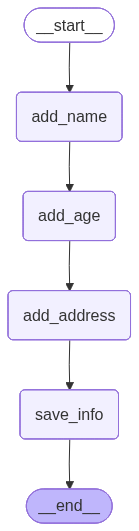

In [34]:
# Graph의 구조를 시각화.
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [ ]:
# 호출
res = graph.invoke({}) # State에 저장할 값을 dict로 전달.
# res = graph.invoke({"save_path":r"c:\src"})
# 반환값(res): State dictionary

-------add_name 노드실행------ <class 'dict'>
add_name에서 state값: {}
----------add_age 노드 실행---------
add_age에서 state값: {'name': '이순신'} 이순신
----------add_address 노드 실행---------
add_address에서 state값: {'name': '이순신', 'age': 30}


In [36]:
res

{'name': '이순신', 'age': 30, 'address': '서울시 금천구 독산동', 'result': 'Fail'}

In [ ]:
for event in graph.stream({"save_path":r"c:\src"}, stream_mode="messages"):
    print("EVENT:", event)
    print('---------------------------------------')

# stream({}, stream_mode="모드")
# 모드: updates (기본) -> 각 Node가 끝날때 마다 그 노드가 반환한 state를 반환 {"노드이름": {state}}
#       values -> 각 노드가 종료될때 마다 그 시점의 전체 state를 반환.
#       messages -> LLM의 응답 chunck(토큰)을 반환. (chatbot 에서 사용.)

-------add_name 노드실행------ <class 'dict'>
add_name에서 state값: {'save_path': 'c:\\src'}
----------add_age 노드 실행---------
add_age에서 state값: {'save_path': 'c:\\src', 'name': '이순신'} 이순신
----------add_address 노드 실행---------
add_address에서 state값: {'save_path': 'c:\\src', 'name': '이순신', 'age': 30}
c:\src에 이순신, 30, 서울시 금천구 독산동를 저장합니다.


# 다양한 엣지

## 1. **기본 엣지**

- 기본 엣지(Normal Edge)는 한 노드에서 다른 노드로의 단방향의 연결흐름을 의미한다. 이는 가장 단순한 형태의 연결로, 이전 노드의 작업이 완료되면 자동으로 다음 노드로 이동한다.
- 기본 엣지는 다음과 같은 특징을 가진다:
  - **고정된 흐름**: 항상 동일한 다음 노드로 이동한다      
  - **단순한 구조**: 복잡한 조건 없이 순차적으로 실행된다      
  - **예측 가능한 동작**: 실행 전에 전체 흐름을 예측할 수 있다    

## 2. **조건부 엣지**

- 조건부 엣지(Conditional Edge)는 특정 **조건에 따라 다음에 실행할 노드를 동적으로 결정**하는 기능이다. 
- 이를 이용해 제어문적 요소 (조건문, 반복문)을 Workflow에 추가할 수 있다. 
- 그래서 순차적 흐름 뿐 아니라 다양한 흐름의 구조를 구현할 수있게 되어 **복잡한 의사결정 로직**을 구현할 수 있다.
- `add_conditional_edges(source_node, 라우팅_함수, path_map)` 을 이용해 정의 한다. 
    1. **소스 노드(Source Node)**
       -  조건 평가가 시작될 노드의 이름이다.
       -  이 노드가 생성해서 반환한 상태 값의 조건에 따라 다음 실행할 노드가 결정된다.
    2. **라우팅 함수(Routing Function)**
       - 소스 노드 실행 후의 State 값을 바탕으로 다음에 실행할 노드를 결정하는 로직을 포함 제공하는 함수. 
       - **조건에 따라 이동할 다음 노드의 식별값**을 반환한다. (보통 노드 이름을 반환)
    3. **path map - 조건부 엣지 매핑(Conditional Edge Mapping)**
       -  라우팅 함수가 반환한 식별값에 따라 이동할 노드를 설정한 **딕셔너리 또는 리스트**.
       -  라우팅 함수가 반환한 식별값과 이동할 노드의 이름이 **다른 경우 dict로 정의**한다. `{식별값1:이동할노드이름1, 식별값2: 이동할노드이름2, ..}`
       -  라우팅 함수가 반환한 식별값과 이동할 노드의 이름이 **같은 경우 list로 정의**한다.(딕셔너리로 해도 상관 없음) `[이동할노드이름1, 이동할노드이름2, ...]`
    ```python
      # Source 노드
      def llm_answer(state):
        ...
        return {"relevance_score": score}
      
      # 라우팅 함수
      def relevance_check(state):     
          # 관련성 체크 로직    
          if state["relevance_score"] > 0.8:        
              return "grounded"    
          else:        
              return "not_grounded" 

      # path_map (조건부 엣지 매핑)
      mapping = {        
        "grounded": END,           # 라우팅함수의 반환값이 "grounded" 이면 END 노드로 이동
        "not_grounded": "retrieve" # "not_grounded" 이면 "retrieve" 노드로 이동
      }
      
      # 조건부 엣지 정의       
      graph.add_conditional_edges(
          "llm_answer",     # 소스 노드    
          relevance_check,  # 조건 함수    
          mapping
      )
    ```

## 3. **반복 구조**

- LangGraph 핵심 장점 중 하나는 반복 구조(순환 구조)를 지원한다는 점이다. 
- 반복 구조는 조건이 충족될 때까지 같은 Node들을 여러 번 실행할 수 있게 해준다. 
- 반복 구조의 활용 예시:
  - **검색 품질 개선**
    - 검색 결과가 만족스럽지 않을 때 쿼리를 재작성하여 다시 검색한다.
  - **답변 품질 향상**
    - 생성된 답변의 품질이 낮을 때 다시 생성하거나 개선한다.  
  - **할루시네이션 방지**
    -  답변이 검색된 문서와 관련성이 낮을 때 재생성을 요청한다.
  - **Human In The Loop** 
    - HITL 구조에서 사람의 확인·승인이 완료될 때까지 `멈춤(interrupt) → 사람 입력 → 재개 → 조건 불만족 → 다시 같은 Node로 → 다시 멈춤 → ...` 구조를 반복할 수 있게 한다.
  
## 4. **Command**

- `Command`는 노드의 실행 결과로(노드의 반환값) **상태 업데이트와 다음 이동할 노드 지정을 함께 반환**할 수 있게 해주는 기능이다.
- 일반적인 조건부 엣지는 `add_conditional_edges()`를 이용해 그래프 외부에서 흐름 제어 로직을 정의한다.
- 반면 `Command`는 **노드 내부에서 다음 이동 경로를 직접 결정**할 수 있다. 그래서 노드가 직접 조건에 따라 어느 경로로 이동할 지 결정할 수 있다.

- `Command`는 다음과 같은 상황에서 유용하다:
  - 노드 실행 결과에 따라 다음 노드를 동적으로 결정해야 할 때
  - 상태 업데이트와 흐름 제어를 한 번에 처리하고 싶을 때
  - 멀티 에이전트 구조에서 특정 에이전트로 작업을 넘겨야 할 때
  - 조건부 엣지보다 노드 내부 로직 중심으로 흐름을 관리하고 싶을 때
  - `Command`를 반환하는 노드함수의 반환 타입에 이동 가능한 노드 이름을 명시하는 type hint를 추가 하는 것이 권장된다.
  
- `Command`의 파라미터:
  1. **update**
     - State에 반영할 값을 dict로 지정한다.
     - 일반 노드에서 `return {"key": value}` 형태로 상태를 업데이트하는 것과 유사하다.
  2. **goto**
     - 다음에 실행할 노드 이름을 지정한다.
     - 라우팅을 Command로 직접 제어할 때 사용하며, **조건부 엣지 없이 동적 라우팅을 할 수 있다**.
     - 보통 처리 결과에 따라 특정 노드로 이동해야 하는 코드를 Node내에 직접 구현할 때 사용한다.
     - Command를 이용한 이동은 **상태 업데이트와 라우팅을 함께 해야 할 때 사용**한다. 만약 **상태 업데이트 없이 라우팅만 필요하면 조건부 엣지를 쓰는 것이 권장**된다.
  3. **graph**
    - `graph`는 `goto`로 지정한 **이동 대상 노드가 현재 graph가 아니라 parent graph에 있을 때** 사용한다.
       - 기본적으로 `goto`는 현재 graph 안의 노드를 대상으로 한다.
       - 하지만 현재 실행 중인 노드가 subgraph 내부에 있고, 이동하려는 노드가 parent graph에 있다면 `graph=Command.PARENT`를 지정한다.
       - 주로 **멀티에이전트 구조**에서 특정 sub agent 내부 노드가 parent graph에 등록된 다른 agent 노드나 supervisor 노드로 handoff할 때 사용한다.
         > - Handoff: 현재 작업을 수행 중인 에이전트가 다른 에이전트에게 작업의 주도권(Control)을 넘기는 것을 의미한다.
    
      ```python
        def sub_agent_node(state) -> Command:
          return Command(
              update={"result": "sub agent 작업 결과"},
              goto="parent_agent_node",
              graph=Command.PARENT
          )
      ```
  4. **resume**
    - interrupt()로 일시중단된 그래프를 재개할 때 그래프에 전달할 값지정.

### Command 예
  ```python
  from typing import Literal
  from langgraph.graph import END
  from langgraph.types import Command

  
  #  반환 타입에 이동 가능한 노드 이름을 명시하는 type hint를 추가한다. Command[Literal['이동노드 이름', ...]]
  # `Command[Literal["retrieve", "answer", "__end__"]]`:  이 노드가 `retrieve`, `answer`, `END`로 이동할 수 있음을 나타낸다.
  def router_node(state) -> Command[Literal["retrieve", "answer", "__end__"]]:
      question = state["question"]

      if "검색" in question:
          # 상태를 업데이트 하면서 이동한다.
          return Command(
              update={"route": "retrieve"},
              goto="retrieve"
          )

      elif "답변" in question:
          return Command(
              update={"route": "answer"},
              goto="answer"
          )

      else:
          return Command(
              update={"route": "end"},
              goto=END
          )
  ```
### Conditional Edge(조건부 엣지)와 Command의 차이

| 구분          | Conditional Edge             | Command                           |
| ------------ | ---------------------------- | --------------------------------- |
| 흐름 제어 위치 | 그래프 정의부                   | 노드 내부                          |
| 상태 업데이트  | 노드 반환값에서 처리             | `Command(update=...)`에서 처리     |
| 다음 노드 결정 | 조건 함수가 결정                | 노드가 직접 결정                     |
| 적합한 경우   | 흐름 구조를 명확히 분리하고 싶을 때 | 노드 결과에 따라 즉시 분기하고 싶을 때  |
| 사용 예       | 분류기, 라우터, 반복 조건        | 에이전트 핸드오프, 동적 라우팅, 상태 업데이트 + 이동 |


## 5. **Send**

- `Send`는 하나의 노드에서 **여러 개의 작업을 동적으로 생성하여 다른 노드로 전달**할 때 사용하는 기능이다.
- 주로 병렬 처리, map-reduce 패턴, 여러 에이전트에게 작업 분배, 여러 문서나 항목에 대한 반복 처리에 사용된다.
- 일반 엣지나 조건부 엣지는 보통 다음 노드를 **하나만 선택**한다.
- 반면 `Send`는 다음 실행할 노드를 여러 번 호출할 수 있다.
- 각각의 호출에는 서로 다른 State 값을 전달할 수 있다.
- `Send`는 다음과 같은 상황에서 유용하다:

  - 여러 문서를 각각 요약해야 할 때
  - 여러 검색 쿼리를 동시에 처리해야 할 때
  - 여러 에이전트에게 작업을 나누어 맡겨야 할 때
  - 리스트의 각 항목을 개별 노드에서 처리해야 할 때
  - map-reduce 구조를 구현해야 할 때
    > map-reduce란 **큰 작업을 여러 개의 작은 작업으로 분할(Map)하여 병렬 처리한 뒤, 그 결과를 하나로 합치는(Reduce) 처리 방식**을 말한다.

- `Send` 파라미터
  - **node**: 실행할 대상 노드의 이름
  - **arg**
    -  대상 노드에 전달할 입력 state field. 
    -  전체 그래프의 State schema에 없는 Field들을 전달 할 수 있다. 즉 전체 State와 다른 입력 State를 전달할 수 있다. 
  
### Send 사용 예시

```python
from langgraph.types import Send

def send_each_document(state):
    documents = state["documents"]

    return [
        Send("summarize_document", {"document": doc})
        for doc in documents
    ]
```
-  `send_each_document`는 `documents` 리스트를 순회하면서 각 문서를 `summarize_document` 노드로 보낸다.
- 문서가 3개라면 `summarize_document` 노드가 3번 실행된다. 그래서 다음과 같은 효과가 난다.
   ```python
   [
     Send("summarize_document", {"document": doc1}),
     Send("summarize_document", {"document": doc2}),
     Send("summarize_document", {"document": doc3}),
   ]
   ```
- 각 실행에는 서로 다른 `document` 값이 전달된다.

#### 전체 코드(Map-Reducer 구조)

```python
from typing import Annotated, TypedDict
import operator

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


class State(TypedDict):
    documents: list[str]
    summaries: Annotated[list[str], operator.add] # 병렬처리되어 반환된 결과들을 모을 Field. 여러 노드 실행 결과가 누적되어야 하므로 Reducer가 필요.
    final_summary: str


# 1. 조건부 엣지가 시작될 source node
def distribute_node(state: State):
    
    # 여기서  파일, DB, 검색 결과 등에서 문서 목록을 가져올 수 있다.

    return {"documents": 조회한 문서 목록(Document List)}


# 2. Send 객체들을 반환하는 routing function
def send_each_document(state: State):
    return [
        Send("summarize_document", {"document": doc}) # Send로 state를 전달 할 때 State Schema에 없는 Field들을 전달 할 수 있다. 
                                                      # (여기서는 `summarize_document`를 호출할 때 전체 state에는 없는 document를 전달하고 있다.) 
        for doc in state["documents"]
    ]


# 3. 각 문서를 개별 요약하는 node
def summarize_document(state):
    document = state["document"]

    summary = llm.invoke(document) # 요약 작업을 LLM에게 요청

    return {"summaries": [summary]}


# 4. 여러 요약 결과를 최종 요약으로 합치는 node
def final_summary(state: State):
    summaries = state["summaries"]

    return {
        "final_summary": "\n".join(summaries)
    }
```

- 그래프 구성

```python
graph = StateGraph(State)

graph.add_node("distribute_node", distribute_node)
graph.add_node("summarize_document", summarize_document)
graph.add_node("final_summary", final_summary)

graph.add_edge(START, "distribute_node")

graph.add_conditional_edges(
    "distribute_node",       # source node 이름
    send_each_document,      # routing function
    ["summarize_document"]   # 가능한 목적지 노드 목록
)

graph.add_edge("summarize_document", "final_summary")
graph.add_edge("final_summary", END)
```

- 이 구조는 다음과 같은 흐름으로 동작한다.

![send](figures/langgraph_send.png)

summarize_document  ← 문서 개수만큼 여러 번 실행 된다.

### Send와 반복 구조의 차이

| 구분    | 반복 구조                | Send               |
| ------- | -------------------- | ------------------ |
| 목적    | 조건이 만족될 때까지 같은 흐름 반복 | 여러 작업을 나누어 실행        |
| 실행 방식 | 순환 구조                         | 분산 실행 / 병렬 처리 구조     |
| 사용 예  | 답변 재생성, 검색 재시도           | 여러 문서 요약, 여러 쿼리 검색 |
| 핵심 개념 | Loop(같은 흐름을 다시(반복)실행)  | Fan-out (하나의 흐름이 여러 갈래로 퍼지는 구조)  |
| 결과 처리 | 상태를 갱신하며 반복              | 여러 결과를 모아 병합          |

* 정리하면, 반복 구조는 **하나의 작업을 조건이 만족될 때까지 다시 실행하는 방식**이다.
* `Send`는 **여러 작업을 동시에 또는 독립적으로 나누어 실행하는 방식**이다.


In [47]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from typing import Annotated
from typing_extensions import TypedDict

from datetime import date 

In [ ]:
# name: Annotated[str,  "고객의 이름"]

In [53]:
# State Schema 설계
class State(TypedDict):
    messages: Annotated[list, add_messages] # list에 노드가 반환한 리스트의 값들을 append
    # Annotated[타입, 함수(reducer)] # 노드가 반환한 값을 어떻게 State에 저장할지 결정하는 함수-reducer

In [ ]:
# State : {"messages":[1, 2, 3], "name":xxxxx, "age": 30}

# def xxxxx(state):
#     return {"messages":[10, 20]"}
# Node의 반환값: {"messages":[10, 20]}

# Schema: messages: list => State {"messages": [1, 2, 3]=>[10, 20]}
# messages:Annotated[list, add_messages] => State{"messages": add_messages([1, 2, 3], [10, 20])}

add_messages([HumanMessage(content="A")], [HumanMessage(content="B")])
# left_list + right_list


[HumanMessage(content='A', additional_kwargs={}, response_metadata={}, id='a955d250-05e3-4e7b-a2d1-ab3e3d84fde5'),
 HumanMessage(content='B', additional_kwargs={}, response_metadata={}, id='b1c8148d-1f14-4632-bd00-51c4989e7ef3')]

In [ ]:
import operator
operator.add([1, 2, 3], [10, 20 ,30])

[1, 2, 3, 10, 20, 30]

In [57]:
system_prompt = """당신은 다양한 지식을 제공하는 AI 어시스턴트입니다. 
주요 목표는 사용자의 요청에 대한 정확한 정보를 이해하기 쉽게 설명하는 것입니다.

# Instruction:
정확한 답변을 위해 웹 검색이 필요하거나 최신 정보를 얻고 싶을 때는 tavily_search 도구를 사용하십시오. 이 도구는 인터넷 검색을 통해 정보를 검색해서 제공합니다.
최신 정보를 제공해야 할 때는 {today} 를 기준으로 합니다.
검색 결과를 기반으로 명확하고 간결한 답변을 제공하십시오.
최종 응답은 챗봇과 같은 대화형 스타일을 유지하세요. 친근하고 쉽고 자연스럽게 답변하되 전문성을 보이는 어조를 유지하세요.

각 도구들을 결합해서 사용자의 요청에 정확한 대답을 하세요.
항상 가장 최신의 정확한 정보를 제공하기 위해 노력하세요."""

prompt = ChatPromptTemplate(
    [
        ("system", system_prompt),
        ("human", "{query}")
    ],
    partial_variables={"today": date.today().strftime("%Y년 %m월 %d일")}
)
tools = [TavilySearch(max_result=5)]
model = ChatOpenAI(model="gpt-5.4-mini").bind_tools(tools=tools)
chain = prompt | model 

def chatbot_node(state: State):
    """LLM 모델을 호출하는 노드함수."""
    # State에서 사용자가 invoke시 전달한 메세지를 읽어서 llm 호출
    response = chain.invoke({"query":state['messages']}) # 반환: [HM, AI, TM, TM]
    return {"messages":[response]}

In [58]:
class CustomToolNode:
    """Node: Callable 클래스로 구현
    Tool을 호출해서 실행하는 노드. 그 결과(ToolMessage)를 State의 messages:list 에 추가    
    """
    def __init__(self, tools:list):
        # tools: list[StructuedTool] # 툴들을 리스트로 받는다.
        self.tool_by_name = { tool.name:tool for tool in tools} # dict[툴이름:Tool객체]

    # 노드함수
    def __call__(self, state:State):
        messages = state.get("messages", []) # State에서 messages 필드 조회 
        if messages:
            message = messages[-1] # 마지막 Message를 조회(chatbot_node의 반환값)
        else:
            raise Exception("State에 message가 없습니다.")
        
        # Tool 호출
        outputs = [] # tool 호출결과(ToolMessage)를 담을 리스트
        for tool_call in message.tool_calls: # list[dict-개별 tool호출]
            tool_messages = self.tool_by_name[tool_call['name']].invoke(tool_call)
            outputs.append(tool_messages)
        
        return {"messages": outputs}
    
# tool_node 정의
tool_node = CustomToolNode(tools=tools)    
# chatbot_node(model에 binding된 툴들)가 사용하는 tool들을 전달.

In [59]:
# 조건부 엣지에 지정할 router 함수 정의
def custom_tool_condition(state:State):
    """출발지노드(chatbot_node)의 결과(AIMessage)가 tool 호출 tool_node로 이동
                                 결과가 LLM 응답이면 END 노드(종료)로 이동
       판단 기준: AIMessage의 tool_calls 속성에 값이 있는지 여부.
    """
    messages = state.get("messages", [])
    if messages:
        message = messages[-1]
    else:
        raise Exception("State에 message가 없습니다.")
    
    if message.tool_calls and len(message.tool_calls) > 0: # AIMessage에 tool_call 이 있다면.
        return "tools" # 다음 실행 노드를 식별할 수있는 값을 반환(보통 node이름)
    else: # AIMessage에 최종 응답(content)이 있는 경우.
        return END


In [ ]:
# StateGraph 정의 = node추가, edge연결 => compile

workflow = StateGraph(State)
# 노드추가
workflow.add_node("chatbot", chatbot_node)
workflow.add_node("tool_node", tool_node)
# 엣지 연결 
workflow.add_edge(START, "chatbot")
workflow.add_conditional_edges(
    "chatbot", # 시작(출발지) 노드
    custom_tool_condition, # router 함수
    {"tools":"tool_node", END:END} # Path Map (router의 리턴값에 따라 어느 노드로 이동할지 지정)
)
# Path Map: 식별자와 이동할 노드이름이 같은 경우 ["tool_node", END] -> {"tool_node":"tool_node", END:END}
workflow.add_edge("tool_node", "chatbot")

# 컴파일
graph = workflow.compile()

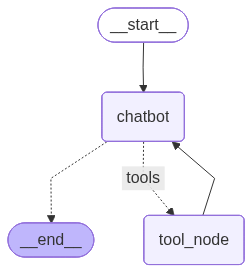

In [62]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [ ]:
res = graph.invoke(
    {
        "messages":[("human", "안녕")]
    }
)

In [64]:
res

{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}, id='118836d5-0d3c-4881-9eb1-47670102ea3d'),
  AIMessage(content='안녕하세요! 😊  \n무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1506, 'total_tokens': 1523, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzcdYVty3n70cPBe4fU5vVbCBUedo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f4596-30a8-7882-9730-089ecb09c80d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1506, 'output_tokens': 17, 'total_tokens': 1523, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 

In [65]:
res2 = graph.invoke({
    "messages":[("human", "AI의 최신동향에 대해서 조사해서 설명해줘.")]
})

In [67]:
res2["messages"]

[HumanMessage(content='AI의 최신동향에 대해서 조사해서 설명해줘.', additional_kwargs={}, response_metadata={}, id='7a34ceff-f37d-4f1b-931b-46aa30ffc0e5'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 1517, 'total_tokens': 1575, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzchlwZ26b1uS3yNlgWifgldHUsca', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f459a-30cd-7080-913a-e13b2c44053b-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'AI 최신 동향 2026 인공지능 최신 트렌드 주요 동향 2026', 'search_depth': 'advanced', 'topic': 'general', 'time_range': 'year', 'include_images': False}, 'id': 'call_YdP1cXwdr

In [69]:
print(res2["messages"][-1].content)

최근 AI 동향을 한마디로 요약하면, **“생성형 AI를 넘어서 에이전트 AI, 물리적 AI, 기업용 실전 도입”**으로 중심이 이동하고 있습니다.  
아래처럼 정리해드릴게요.

## 1) AI 에이전트(Agentic AI)가 핵심 화두
이제 AI는 질문에 답하는 수준을 넘어, **스스로 계획하고 실행하는 ‘디지털 동료’**로 진화하고 있습니다.

- 단순 챗봇 → 업무를 끝까지 처리하는 에이전트
- 예: 일정 조율, 문서 작성, 코드 수정, 리서치 요약, 업무 자동화
- 기업들은 여러 에이전트를 묶어 **멀티 에이전트 워크플로**를 구축하는 방향으로 가고 있습니다

즉, AI를 “도구”로 쓰는 단계를 지나 **“일하는 주체”로 활용**하는 흐름이 강해졌습니다.

## 2) 물리적 AI와 로보틱스 확대
AI가 화면 속 소프트웨어를 넘어 **현실 세계**로 들어오고 있습니다.

- 자율주행, 물류창고, 제조, 의료, 건설
- 휴머노이드 로봇, 산업 자동화
- 센서·카메라·제어 시스템과 결합한 **Physical AI** 확산

앞으로는 “말을 잘하는 AI”보다 **보고, 판단하고, 움직이는 AI**가 중요해질 가능성이 큽니다.

## 3) 기업 도입의 중심은 “실험”에서 “ROI”
요즘 기업들은 AI를 그냥 도입하는 게 아니라,  
**실제 비용 절감과 생산성 향상으로 이어지는지**를 훨씬 엄격하게 봅니다.

- PoC(실험) 중심 → 실제 운영 중심
- 보안, 데이터 주권, 권한 관리가 핵심
- 프롬프트 인젝션, 데이터 유출 같은 리스크 대응 필요

특히 기업용 AI는 **성능만큼 신뢰성과 보안**이 중요합니다.

## 4) AI 인프라 경쟁이 더 치열해짐
AI 성능 경쟁은 결국 **GPU, 데이터센터, 전력, 냉각, 네트워크** 경쟁입니다.

- 빅테크의 AI 인프라 투자 확대
- 더 효율적인 모델, 더 스마트한 인프라가 중요
- “큰 모델”만이 아니라 **비용 대비 효율**이 중요한 지표로 떠오름

즉, AI 산업은 점점 **반도체·전력·클라우드 산업과 한

In [70]:
res3 = graph.invoke({
    "messages": [("human","러시아 우크라이나 전쟁과 미국 이란 전쟁의 최신 상황을 알려줘.")]
})

In [71]:
res3['messages']

[HumanMessage(content='러시아 우크라이나 전쟁과 미국 이란 전쟁의 최신 상황을 알려줘.', additional_kwargs={}, response_metadata={}, id='f45a8ade-6c20-43cd-abcc-845df0615f28'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 115, 'prompt_tokens': 1522, 'total_tokens': 1637, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-Dzcl3LEwmhZBl6CaJgI6CbC7c2Emg', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f459d-4bdb-7223-8ee6-7c8f4295e159-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Russia Ukraine war latest situation July 2026 ceasefire frontline diplomacy sanctions', 'topic': 'news', 'search_depth': 'advanced', 'time_range

In [72]:
print(res3['messages'][-1].content)

물론입니다. **2026년 7월 9일 기준 최신 흐름**으로 보면, 두 전쟁 모두 “완전한 종전”보다는 **소강·확전이 반복되는 불안정한 상태**에 가깝습니다.

## 1) 러시아-우크라이나 전쟁 최신 상황
- **전선은 여전히 치열하지만, 러시아의 큰 돌파는 제한적**입니다.
- 우크라이나는 **무인기·장거리 타격**으로 러시아의 **보급로, 군수기지, 연료 저장시설**을 계속 공격하고 있습니다.
- 최근 보도들에 따르면 우크라이나는 2026년 들어 **상당한 면적을 되찾았고**, 러시아의 전진 속도는 예전보다 둔화되거나 일부 구간에서 역전되는 모습도 있습니다.
- 다만 전반적으로는 **동부와 남부 전선이 계속 불안정**하고, 하루 교전 수가 많은 **소모전 양상**입니다.
- EU는 러시아의 **에너지 수익과 전쟁경제**를 겨냥한 새 제재를 계속 강화하고 있습니다.

### 한줄 요약
**우크라이나는 방어만 하는 게 아니라 반격도 확대 중이고, 러시아는 계속 압박하지만 결정적 우세를 만들지 못하는 상황**입니다.

---

## 2) 미국-이란 전쟁 최신 상황
- 이 전쟁은 현재 **아주 불안한 휴전/합의 상태**를 유지하는 중입니다.
- 하지만 **완전한 평화는 아니고, 충돌이 간헐적으로 재발**하고 있습니다.
- 최근 보도에 따르면:
  - **호르무즈 해협**에서 선박 공격·미사일 관련 긴장이 이어졌고,
  - 미국은 이에 대응해 **이란의 방공·발사 시설을 타격**했다는 보도가 나왔습니다.
- 이란은 **즉각 대응** 가능성을 경고하고 있고,
- 미국과 이란은 **외교 협상과 군사 충돌이 동시에 진행되는 매우 취약한 상태**입니다.
- 핵심 쟁점은 여전히 **호르무즈 해협 통제**, **휴전 유지**, **핵·안보 합의**입니다.

### 한줄 요약
**미국-이란은 전면전은 피했지만, 휴전이 매우 불안정해서 작은 충돌이 큰 위기로 번질 수 있는 상태**입니다.

---

## 전체적으로 보면
- **러시아-우크라이나 전쟁**: 장기전, 소모전, 우크

In [73]:
############### stream 으로 조회
gen = graph.stream(
    {
        "messages":[("human","러시아 우크라이나 전쟁과 미국 이란 전쟁의 최신 상황을 알려줘.")]
    }
)
gen

<generator object Pregel.stream at 0x0000028C83025550>

In [74]:
for event in gen:
    print(event)
    print("--------------------------------")

{'chatbot': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 1520, 'total_tokens': 1639, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzcoOQqZPTKvI9qPXGT9Wm88oKdac', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f45a0-7524-7c90-874a-30b1e662a823-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Russia Ukraine war latest situation July 2026 ceasefire front line diplomacy casualties recent developments', 'search_depth': 'advanced', 'topic': 'news', 'time_range': 'month', 'include_images': False}, 'id': 'call_JduJyDPrE6KoXk3gmwPz9ziN', 'type': 'tool_call'}, {'name

In [81]:
gen = graph.stream(
    {
        "messages":[("human","러시아 우크라이나 전쟁과 미국 이란 전쟁의 최신 상황을 알려줘.")]
    }, 
    stream_mode="messages" # tuple[응답Chunk, metadata: 어떤 노드의 답인지]
)

for i, event in enumerate(gen):
    if event[1]["langgraph_node"]=="chatbot":   # 응답메세지를 출력하는 Node이름
        print(event[0].content, end="")
    # print(event[0])
    # print(event[1])
    # if i == 0:
    #     break

물론이죠. **2026년 7월 9일 기준**으로, 두 전쟁의 최신 상황을 간단히 정리해드릴게요.

## 1) 러시아-우크라이나 전쟁 최신 상황
- **러시아가 우크라이나 전역, 특히 키이우에 대한 공습을 계속 강화**하고 있습니다.
- AP 보도에 따르면 **7월 8일 러시아의 드론·미사일 공격으로 우크라이나 전역에서 최소 4명이 사망**했고, **키이우가 이틀 연속 타격**을 받았습니다.
- 6월 말에도 러시아 공격으로 **우크라이나에서 12명 사망, 40명 부상**이 있었고, 러시아는 대규모 보복 공습을 이어가고 있습니다.
- 동시에 **우크라이나도 러시아 에너지 인프라를 겨냥한 드론 공격**을 강화하고 있으며, 러시아 남부의 정유시설에 불이 난 사례도 보도됐습니다.
- 전반적으로 **전선은 소모전 양상**, 러시아는 공습 압박을 늘리고, 우크라이나는 러시아 후방의 군사·에너지 목표를 타격하는 흐름입니다.

## 2) 미국-이란 전쟁 최신 상황
- **미국이 이란을 상대로 새로운 공습을 단행**했다는 AP 보도가 7월 9일자에 나왔습니다.
- 보도에 따르면 미국의 공습 이후 **이란이 페르시아만 주변의 걸프 아랍 국가들에 반격성 움직임**을 보였고, **쿠웨이트·카타르·바레인에서 경보가 활성화**됐습니다.
- 트럼프 대통령은 **호르무즈 해협에서의 이란의 상선 공격에 대한 보복**이라고 언급했고, **추가 공습 가능성도 경고**했습니다.
- 6월 중순에는 **미국과 이란이 전쟁 종식을 위한 합의에 도달했다는 보도**도 있었지만, 이후 상황이 다시 악화되며 **휴전/협상은 매우 불안정한 상태**로 보입니다.
- 핵심은 지금 **직접 충돌이 다시 격화되는 국면**이라는 점입니다.

## 한줄 요약
- **러시아-우크라이나:** 러시아의 대규모 공습이 계속되고, 우크라이나는 러시아 후방 인프라를 타격하는 소모전이 지속 중.
- **미국-이란:** 미국 공습 이후 이란의 반격 가능성이 커지며, 걸프 지역 긴장이 급격히 높아진 상황.

원하시면 제가 다음 단계로
1

In [80]:
graph.invoke({
    "messages":[("human", "내가 아까한 질문에 대해 좀더 자세히 알려줘.")]
})

{'messages': [HumanMessage(content='내가 아까한 질문에 대해 좀더 자세히 알려줘.', additional_kwargs={}, response_metadata={}, id='bc06cec0-b5c1-426c-97b9-aee3b5173fac'),
  AIMessage(content='물론이죠. 그런데 지금 대화만으로는 **“아까 한 질문”의 내용이 보이지 않아서** 어떤 주제를 더 자세히 설명해야 할지 알 수 없어요.\n\n아래 중 하나로 보내주시면 바로 자세히 설명해드릴게요:\n1. **아까 질문을 그대로 다시 적어주기**\n2. **키워드만 적어주기**  \n   예: “챗GPT 요금제”, “주식 투자”, “파이썬 리스트”\n3. **대략적인 맥락 설명하기**  \n   예: “아까 여행 추천 물어봤어”, “아까 건강 관련 질문이었어”\n\n원하시면 제가  \n- **쉽게 풀어서 설명**하거나  \n- **예시까지 포함해서**  \n- **핵심만 요약해서**  \n답변드릴게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 191, 'prompt_tokens': 1517, 'total_tokens': 1708, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DzdBSaOQlOshBIm9xo7